In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns

In [2]:
data_dir = "./pbmc3k/"

adata = sc.read_10x_mtx(
    data_dir,
    var_names='gene_symbols',  # or 'ensembl_ids' if you prefer
    make_unique=True            # ensure gene names are unique
)
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

In [3]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
adata

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids', 'mt', 'ribo', 'hb'

In [4]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True
)

In [5]:
adata = adata[adata.obs['pct_counts_mt'] < 15, :].copy()

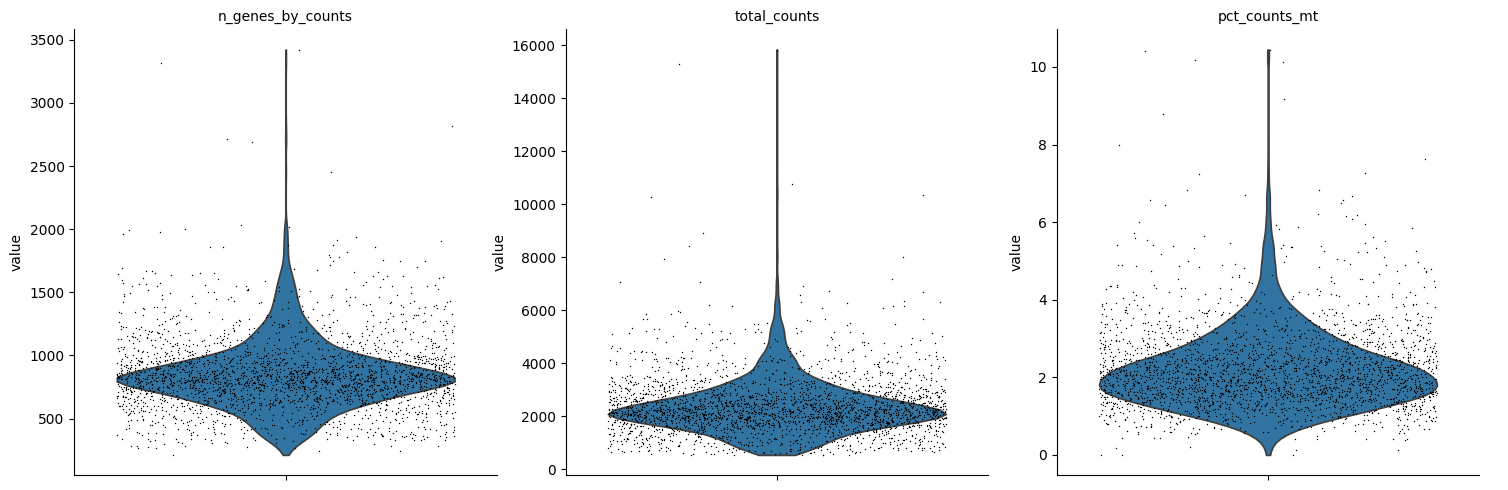

In [16]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    save="pbmc3k_qc.png"
)

In [6]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [7]:
adata.layers["counts"] = adata.X.copy()

In [8]:
# Normalizing to median total counts
sc.pp.normalize_total(adata, target_sum=10**4)
# Logarithmize the data
sc.pp.log1p(adata)

In [20]:
adata.X = adata.X.toarray()

In [21]:
import celltypist
from celltypist import models

In [22]:
models.download_models(
    force_update=True, model=["Immune_All_Low.pkl", "Immune_All_High.pkl"]
)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /home/shreyansh/.celltypist/data/models
💾 Total models to download: 2
💾 Downloading model [1/2]: Immune_All_Low.pkl
💾 Downloading model [2/2]: Immune_All_High.pkl


In [23]:
model_high = models.Model.load(model="Immune_All_High.pkl")
model_high

CellTypist model with 32 cell types and 6639 features
    date: 2022-07-16 08:53:00.959521
    details: immune populations combined from 20 tissues of 18 studies
    source: https://doi.org/10.1126/science.abl5197
    version: v2
    cell types: B cells, B-cell lineage, ..., pDC precursor
    features: A1BG, A2M, ..., ZYX

In [24]:
predictions_high = celltypist.annotate(
    adata, model=model_high, majority_voting=True
)

🔬 Input data has 2698 cells and 13714 genes
🔗 Matching reference genes in the model
🧬 4178 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/data1/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-08 18:14:37.340057: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 18:14:37.392511: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critica

In [25]:
predictions_high_adata = predictions_high.to_adata()
adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "majority_voting"
]
adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
    adata.obs.index, "conf_score"
]
adata.obs

,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,...,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_genes,predicted_labels,over_clustering,majority_voting,conf_score,celltypist_cell_label_coarse,celltypist_conf_score_coarse
AAACATACAACCAC-1,781,6.661855,2421.0,7.792349,47.748864,63.279637,74.969021,88.393226,73.0,4.304065,...,0.0,0.000000,0.000000,781,T cells,0,T cells,0.998940,T cells,0.998940
AAACATTGAGCTAC-1,1352,7.210080,4903.0,8.497807,45.502753,61.023863,71.813176,82.622884,186.0,5.231109,...,0.0,0.000000,0.000000,1352,B cells,2,B cells,0.999804,B cells,0.999804
AAACATTGATCAGC-1,1131,7.031741,3149.0,8.055158,41.314703,53.794856,65.449349,79.961893,28.0,3.367296,...,0.0,0.000000,0.000000,1131,T cells,3,T cells,0.999761,T cells,0.999761
AAACCGTGCTTCCG-1,960,6.867974,2639.0,7.878534,39.029936,52.898825,66.691929,82.569155,46.0,3.850148,...,0.0,0.000000,0.000000,960,Monocytes,4,Monocytes,0.999745,Monocytes,0.999745
AAACCGTGTATGCG-1,522,6.259581,981.0,6.889591,44.852192,55.657492,67.176351,97.757390,12.0,2.564949,...,0.0,0.000000,0.000000,522,ILC,5,ILC,1.000000,ILC,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTCGAACTCTCAT-1,1155,7.052721,3461.0,8.149602,39.237215,52.528171,65.761341,81.074834,73.0,4.304065,...,1.0,0.693147,0.028893,1155,Monocytes,4,Monocytes,0.902160,Monocytes,0.902160
TTTCTACTGAGGCA-1,1227,7.113142,3447.0,8.145550,37.278793,51.900203,63.881636,78.909196,32.0,3.496508,...,0.0,0.000000,0.000000,1227,Plasma cells,2,B cells,0.920468,B cells,0.920468
TTTCTACTTCCTCG-1,622,6.434547,1684.0,7.429521,45.783848,61.638955,74.940618,92.755344,37.0,3.637586,...,0.0,0.000000,0.000000,622,B cells,25,B cells,0.999951,B cells,0.999951
TTTGCATGAGAGGC-1,454,6.120297,1024.0,6.932448,48.046875,62.402344,75.195312,100.000000,21.0,3.091043,...,0.0,0.000000,0.000000,454,B cells,41,B cells,0.999940,B cells,0.999940


In [14]:
adata.obs[['celltypist_cell_label_coarse']].to_csv('./pbmc3k_Result/pbmc3k_celltypist_labels.csv')

In [11]:
import scanpy as sc
import pandas as pd
import os

# Set output directory
output_dir = "pbmc3k1_Result"
os.makedirs(output_dir, exist_ok=True)

# Parameters
hvg_list = [1000]
leiden_resolutions = [0.02, 0.5, 2.0]

for n_hvg in hvg_list:
    print(f"\n--- Processing {n_hvg} HVGs ---")
    
    # Work on a copy to avoid overwriting adata
    adata_hvg = adata.copy()
    
    # Step 1: Select highly variable genes
    sc.pp.highly_variable_genes(adata_hvg, n_top_genes=n_hvg)
    hvg_genes = adata_hvg.var[adata_hvg.var['highly_variable']].index.to_list()
    # pd.Series(hvg_genes).to_csv(f"{output_dir}/HVG{n_hvg}_genes.csv", index=False, header=['gene'])
    adata_hvg = adata_hvg[:, adata_hvg.var['highly_variable']].copy()

    # Step 2: PCA
    sc.tl.pca(adata_hvg, svd_solver='arpack')

    # Step 3: Compute neighbors
    sc.pp.neighbors(adata_hvg)
    sc.tl.umap(adata_hvg)
    
    for res in leiden_resolutions:
        print(f" → Running Leiden (resolution={res})")

        adata_hvg1 = adata_hvg.copy()

        # Step 4: Cluster
        sc.tl.leiden(adata_hvg1, resolution=res, key_added=f'leiden_{res}', flavor="igraph")
        
        # Step 5: Export annotated data
        leiden_key = f'leiden_{res}'
        out_prefix = f"HVG{n_hvg}_leiden{res}"
        
        # Save annotated data
        adata_hvg1.obs.to_csv(f"{output_dir}/{out_prefix}_clusters.csv")
        sc.pl.umap(
            adata_hvg1,
            color=[leiden_key, 'celltypist_cell_label_coarse'],
            legend_loc="on data",
            show=False,
            save=f"pbmc3k1_{n_hvg}_{leiden_key}_umap.png"
        )
        # Step 6: Find top 20 marker genes for each cluster
        sc.tl.rank_genes_groups(adata_hvg1, groupby=leiden_key, method='wilcoxon')
        markers = adata_hvg1.uns['rank_genes_groups']
        groups = markers['names'].dtype.names
        top20_list = []
        for g in groups:
            df = pd.DataFrame({g: markers['names'][g][:20]})
            top20_list.append(df)
        top20 = pd.concat(top20_list, axis=1)
        top20.to_csv(f"{output_dir}/{out_prefix}_top20_genes.csv", index=False)
        
        print(f"   ✓ Saved clusters and top20 genes for {out_prefix}")


--- Processing 1000 HVGs ---


/data1/miniconda3/envs/research/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-08 18:19:41.689724: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-08 18:19:41.740287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-08 18:19:43.475428: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see

 → Running Leiden (resolution=0.02)
   ✓ Saved clusters and top20 genes for HVG1000_leiden0.02
 → Running Leiden (resolution=0.5)
   ✓ Saved clusters and top20 genes for HVG1000_leiden0.5
 → Running Leiden (resolution=2.0)
   ✓ Saved clusters and top20 genes for HVG1000_leiden2.0
